In [1]:
#importing libraries
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
import copy
import time

In [2]:
#configuring the graph display
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython: 
    from IPython import display

In [3]:
def main_program(iterations = 3, ori_types = 2, rows = 4, columns = 4,
                 random_energy_matrix_flag = True, energy_matrix = None, model = None):
    
    if model is None:
        model = list()                         
        n_state, energy_matrix = material_state_init(ori_types, rows, columns, random_energy_matrix_flag, energy_matrix)
        model.append([energy_matrix, -1])   

    else:
        m_ori_types = len(np.unique(model[1][0]))     # model_present_ori_types
        assert ori_types == m_ori_types, "Given number of ori types, %d =/= model stored did not match, %d" %(ori_types, m_ori_types)
        assert rows == len(model[1][0]), "Given number of rows, %d =/= model stored rows, %d " %(rows, len(model[1]))
        assert columns == len(model[1][0][0]), "Given number of columns, %d =/= model stored columns, %d" %(columns, len(model[1][0]))
        
        model = copy.deepcopy(model)
        random_energy_matrix_flag = False
        energy_matrix = model[0][0]
        n_state = model[-1][0]
    
    print("Initial Condition \n")
    
    mis_ori_matrix = np.zeros(shape = (ori_types, ori_types), dtype = int)
    ori_array = list(range(0, ori_types))  
    
    for i in range(rows):
        for j in range(columns):
            if (i+j) % 2 == 0:
                mis_ori_matrix = mis_ori_calculator(n_state, ori_array, mis_ori_matrix, i, j) 
    
    total_energy = state_energy(mis_ori_matrix, energy_matrix)
    disp_letter_matrix(n_state, rows, columns)
    disp_mis_ori_calculations(mis_ori_matrix, energy_matrix, total_energy)
    disp_im(n_state, total_energy, len(model)-1)                 # len(model) = 1 ie energy_matrix
    
    for i in range(len(model), len(model) + iterations):      
        print("Iteration #", i, "\n")
        n_state, mis_ori_matrix, total_energy = next_state(copy.deepcopy(n_state), ori_types, copy.deepcopy(mis_ori_matrix), energy_matrix, copy.deepcopy(total_energy))
        model.append(copy.deepcopy([n_state, total_energy]))         # model = energy_matrix, 1st n_state, 2nd n_state, 3rd n_state,......
        disp_letter_matrix(n_state, rows, columns)
        disp_mis_ori_calculations(mis_ori_matrix, energy_matrix, total_energy)
        #print(energy_matrix)
        disp_im(n_state, total_energy, i)
    #print(energy_matrix)
    return model

In [4]:
def material_state_init(ori_types, rows, columns, random_energy_matrix_flag, energy_matrix):
    
    n_state = []
    while (ori_types !=  len(np.unique(n_state))):                              # Forcing to use all ori types
        n_state = np.random.choice(range(0, ori_types), size=(rows, columns))
    #print(n_state, ori_types)
    
    s = (ori_types, ori_types)
    #print("s", s, ori_types)
    if random_energy_matrix_flag == True:
        energy_matrix = np.random.uniform(low = 0, high = 100, size=(s))
        energy_matrix = energy_matrix + np.transpose(energy_matrix)        
        np.fill_diagonal(energy_matrix, 0)                                  # 0 valued diagonal, symm matrix
        #print(energy_matrix, "d", np.shape(energy_matrix))
    else:
        assert np.shape(energy_matrix) == (ori_types, ori_types), "Energy Matrix is not %dx%d" %(ori_types, ori_types)
        assert -1e-8 < np.all(np.abs(energy_matrix - np.transpose(energy_matrix))) < 1e-8, "Energy Matrix is not symmetric"
    #print("Energy Matrix \n", energy_matrix)
    
    return n_state, energy_matrix

In [5]:
def mis_ori_calculator(n_state, ori_array, mis_ori_matrix, i, j):
    
    # ori_array = 0 (A), 1(B), 2(C), ....
    
    # n_state
    #             [i-1, j] 
    #  [i, j-1]   [i, j]   [i, j+1]
    #            [i+1, j]
    
    rows = len(n_state)
    columns = len(n_state[0])
    
    for k in range(len(ori_array)):                # Identifying the type of ori of lattice-pt at i,j
        if n_state[i][j] == ori_array[k]:

            if i-1 >= 0:                                                     # Up-neighbour-orientation-check
                for l in range(len(ori_array)):
                    if n_state[i-1][j] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1

            if j-1 >= 0:                                                    # Left-neighbour-orientation-check
                for l in range(len(ori_array)):
                    if n_state[i][j-1] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1

            if i+1 <= rows-1:                                               # Bottom-neighbour-orientation-check
                for l in range(len(ori_array)):
                    if n_state[i+1][j] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1

            if j+1 <= columns-1:                                           # Right-neighbour-orientation-check
                for l in range(len(ori_array)):
                    if n_state[i][j+1] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1
    #print("mis_ori Matrix \n", mis_ori_matrix)
    return mis_ori_matrix

In [6]:
def disp_letter_matrix(n_state, rows, columns):
    #print("Internal Number State \n", n_state)
    l_state = np.full((rows, columns),'A')
    for i in range(len(n_state)):
        for j in range(len(n_state[0])):
            l_state[i][j] = chr(n_state[i][j]+65)     # ASCII A = 65
    
    print("Letter State \n", l_state, "\n")

In [7]:
def disp_mis_ori_calculations(mis_ori_matrix, energy_matrix, total_energy):
    #print("mis_ori Matrix \n", mis_ori_matrix)
    #print("Energy Matrix \n", energy_matrix)

    for i in range(len(mis_ori_matrix)):
        for j in range(i, len(mis_ori_matrix)):
            if i == j:
                print("Number of adjacent",chr(65+i),chr(65+j),"latice points is ", str( int((mis_ori_matrix[i][j]+mis_ori_matrix[j][i])/4)) )
            else:
                print("Number of adjacent",chr(65+i),chr(65+j),"latice points is ", str( int((mis_ori_matrix[i][j]+mis_ori_matrix[j][i])/2)) )
    #print("\n")
    print("\nEnergy Matrix \n", energy_matrix, "\n") 
    print("Total Energy of State is ", total_energy)

In [8]:
def disp_im(n_state, total_energy, i = 1):

    #print(n_state)
    plt.title("Iteration: %d  Total Energy: %d" %(i, total_energy))
    #

    plt.imshow(n_state)
    plt.show()
    plt.pause(2)
    if is_ipython: 
        display.clear_output(wait=True)   # Make it false for quick execution

In [9]:
def state_energy(mis_ori_matrix, energy_matrix): 
    
    total_energy = 0
    E = np.multiply(mis_ori_matrix, energy_matrix)
    
    for i in range(len(E)):
        for j in range(i, len(E)):
            if i == j:
                total_energy += (E[i][j] + E[j][i])/4
            else:
                total_energy += (E[i][j] + E[j][i])/2
                
    # True Strain, ε = ln(L/Lo). Here, 96% total reduction happened. ε = ln(0.04Lo/Lo) = -3.21
    # Hi = (1e7 * ε)/(2.2*ε + 1.1) * γ. Here, γ = 0.375 J/m^2, high angle gb energy
    # Hi = 2019037.236 J/m^2

    
    return total_energy

In [10]:
def next_state(n_state, ori_types, mis_ori_matrix, energy_matrix, total_energy):  # 1 Monte Carlo Step (MCS)
    for i in range(int(len(n_state))):
        for j in range(int(len(n_state[0]))):
            n_state, mis_ori_matrix, total_energy = reori_attempt(n_state, ori_types, mis_ori_matrix, energy_matrix, total_energy, i, j)
        
    return n_state, mis_ori_matrix, total_energy

In [11]:
def reori_attempt(n_state, ori_types, mis_ori_matrix, energy_matrix, total_energy, i, j):   
    
    rows = len(n_state)
    columns = len(n_state[0])
    #next_state = next_state_swapper(copy.deepcopy(n_state))
    next_state, next_state_mis_ori_matrix= next_state_majority_neighbour_ori_chosen(copy.deepcopy(n_state), copy.deepcopy(mis_ori_matrix), ori_types)
    next_state_total_energy = state_energy(next_state_mis_ori_matrix, energy_matrix)
    
    energy_diff = next_state_total_energy - total_energy
    if energy_diff <= 0:

        #disp_letter_matrix(next_state, rows, columns)
        #disp_mis_ori_calculations(new_state_mis_ori_matrix, energy_matrix, next_state_total_energy)
        return next_state, next_state_mis_ori_matrix, next_state_total_energy
    
    else:
        kT = 0.2
        p = np.random.uniform(0,1)
        if p < np.exp(-1* energy_diff/kT):
            return next_state, next_state_mis_ori_matrix, next_state_total_energy
        else:
            #return next_state_swap(n_state, ori_types, mis_ori_matrix, energy_matrix, total_energy)
            return n_state, mis_ori_matrix, total_energy
        

In [12]:
def next_state_majority_neighbour_ori_chosen(n_state, mis_ori_matrix, ori_types):
    
    next_state = copy.deepcopy(n_state)
    rows = len(n_state)
    columns = len(n_state[0])
    i = np.random.randint(0, len(next_state))     # A random row is chosen
    j = np.random.randint(0, len(next_state[0]))
    
    neighbours_ori = list()
    if i-1 >=0:
        neighbours_ori.append(n_state[i-1][j])
    if i+1 < columns:
        neighbours_ori.append(n_state[i+1][j])
    if j-1 >=0:
        neighbours_ori.append(n_state[i][j-1])
    if j+1 > rows:
        neighbours_ori.append(n_state[i][j+1])
        
    majority_neighbour_ori = max(neighbours_ori, key = neighbours_ori.count)     # Incase of draw, 1st ori type in neighbour list returned
    
    if neighbours_ori.count(majority_neighbour_ori) < int(len(neighbours_ori)/2):
        return n_state, mis_ori_matrix
    
    else:
        next_state[i][j] = majority_neighbour_ori
        old_pt_mis_ori_matrix = np.zeros(shape = (ori_types, ori_types), dtype = int)
        new_pt_mis_ori_matrix = np.zeros(shape = (ori_types, ori_types), dtype = int)
        ori_array = list(range(0, ori_types))         

        old_pt_mis_ori_matrix = mis_ori_calculator(n_state, ori_array, old_pt_mis_ori_matrix, i, j) 
        new_pt_mis_ori_matrix = mis_ori_calculator(next_state, ori_array, new_pt_mis_ori_matrix, i, j) 

        next_state_mis_ori_matrix = mis_ori_matrix - old_pt_mis_ori_matrix + new_pt_mis_ori_matrix

        return next_state, next_state_mis_ori_matrix

Iteration # 5 

Letter State 
 [['C' 'C' 'B' 'B' 'C' 'B' 'C' 'C']
 ['C' 'C' 'B' 'B' 'C' 'B' 'C' 'C']
 ['C' 'C' 'B' 'B' 'A' 'A' 'C' 'C']
 ['C' 'C' 'B' 'B' 'A' 'A' 'C' 'C']
 ['A' 'A' 'B' 'B' 'A' 'A' 'C' 'C']
 ['A' 'A' 'C' 'C' 'A' 'A' 'C' 'C']
 ['C' 'B' 'C' 'C' 'A' 'A' 'C' 'C']
 ['C' 'B' 'C' 'C' 'A' 'A' 'C' 'D']] 

Number of adjacent A A latice points is  20
Number of adjacent A B latice points is  6
Number of adjacent A C latice points is  14
Number of adjacent A D latice points is  0
Number of adjacent B B latice points is  15
Number of adjacent B C latice points is  16
Number of adjacent B D latice points is  0
Number of adjacent C C latice points is  39
Number of adjacent C D latice points is  2
Number of adjacent D D latice points is  0

Energy Matrix 
 [[  0.          86.09068351 103.04331295 186.44165016]
 [ 86.09068351   0.          43.16817909 174.86541123]
 [103.04331295  43.16817909   0.         174.30930824]
 [186.44165016 174.86541123 174.30930824   0.        ]] 

Total Energ

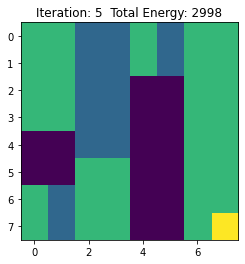

In [13]:
#m = main_program(iterations = 8)
m = main_program(iterations = 5, ori_types = 4, rows = 8, columns = 8, random_energy_matrix_flag = True)

In [ ]:
# END

In [157]:
m

[[array([[  0.        , 123.71800364],
         [123.71800364,   0.        ]]),
  -1],
 [array([[0, 0, 1, 0],
         [0, 0, 0, 0],
         [0, 1, 0, 0],
         [0, 0, 0, 0]]),
  1113.4620327580333],
 [array([[0, 0, 1, 0],
         [0, 0, 0, 0],
         [0, 1, 0, 0],
         [0, 1, 0, 0]]),
  1113.4620327580333],
 [array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 1, 0, 0]]),
  1113.4620327580333],
 [array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]]),
  1113.4620327580333],
 [array([[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]]),
  1113.4620327580333]]

Iteration # 100 

Letter State 
 [['C' 'C' 'C' 'B' 'D' 'B' 'C' 'C' 'C' 'D' 'A' 'A' 'C' 'C' 'C' 'D']
 ['C' 'C' 'C' 'B' 'B' 'A' 'A' 'B' 'B' 'B' 'A' 'A' 'A' 'A' 'B' 'B']
 ['C' 'C' 'B' 'B' 'B' 'A' 'A' 'D' 'B' 'A' 'A' 'A' 'A' 'A' 'B' 'A']
 ['C' 'C' 'B' 'B' 'B' 'D' 'D' 'D' 'B' 'A' 'A' 'A' 'C' 'C' 'B' 'A']
 ['C' 'C' 'A' 'A' 'B' 'D' 'D' 'D' 'B' 'A' 'A' 'C' 'C' 'C' 'B' 'A']
 ['A' 'A' 'A' 'A' 'B' 'D' 'D' 'D' 'B' 'A' 'A' 'C' 'C' 'C' 'B' 'A']
 ['A' 'A' 'A' 'B' 'B' 'D' 'D' 'D' 'D' 'D' 'D' 'C' 'C' 'C' 'B' 'D']
 ['A' 'A' 'A' 'B' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'B' 'C' 'C' 'B' 'D']
 ['A' 'A' 'A' 'D' 'D' 'D' 'B' 'B' 'D' 'D' 'D' 'B' 'C' 'C' 'B' 'B']
 ['A' 'A' 'C' 'D' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'B' 'C' 'C' 'C' 'C']
 ['D' 'B' 'C' 'B' 'D' 'D' 'B' 'A' 'C' 'C' 'C' 'C' 'A' 'A' 'C' 'C']
 ['D' 'D' 'B' 'A' 'A' 'B' 'B' 'A' 'C' 'C' 'C' 'C' 'B' 'A' 'A' 'A']
 ['B' 'B' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'B' 'B' 'B' 'A' 'A' 'A']
 ['C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'D' 'D' 'B' 'C' 'C' 'C' 'C']
 ['C' 'C' 'C' 'C' 'A' 'A' 'A'

In [ ]:
q = [[[1,2], [3,4]], [[5,6], [7,8]]] # A 2x2x2 3-D material state

In [189]:
i2 = np.random.choice([-1,0,1])
i2

1

In [333]:
m

[[array([[ 0.        , 78.66511701],
         [78.66511701,  0.        ]]),
  -1],
 [array([[1, 1, 0, 0],
         [1, 1, 1, 1],
         [0, 1, 1, 0],
         [1, 0, 1, 0]]),
  943.9814040799515],
 [array([[1, 1, 0, 0],
         [1, 1, 1, 1],
         [0, 1, 1, 0],
         [0, 1, 1, 0]]),
  707.9860530599636],
 [array([[1, 1, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0],
         [0, 1, 1, 0]]),
  550.6558190466384],
 [array([[1, 0, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0]]),
  471.99070203997576],
 [array([[1, 1, 0, 0],
         [1, 1, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0]]),
  393.32558503331313],
 [array([[1, 1, 0, 0],
         [1, 1, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0]]),
  393.32558503331313],
 [array([[1, 1, 0, 0],
         [1, 1, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0]]),
  393.32558503331313],
 [array([[1, 1, 0, 0],
         [1, 1, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 0]]),
  393.3

In [79]:
qasd[:2]

[[array([[ 0.        , 78.66511701],
         [78.66511701,  0.        ]]),
  -1],
 [array([[1, 1, 0, 0],
         [1, 1, 1, 1],
         [0, 1, 1, 0],
         [1, 0, 1, 0]]),
  943.9814040799515]]

In [78]:
qasd[1][0]

array([[1, 1, 0, 0],
       [1, 1, 1, 1],
       [0, 1, 1, 0],
       [1, 0, 1, 0]])

In [225]:
#np.save('model_5x5_2type_np.npy', np.array(m, dtype = object))

In [36]:
poqasd = np.load('model1_np.npy', allow_pickle=True)

In [37]:
qasd = poqasd.tolist()

In [81]:
q = main_program(iterations = 10, ori_types = 2, rows = 4, columns = 4,
                 random_energy_matrix_flag = True, model = qasd[:2])

Iteration # 11 

Letter State 
 [['A' 'A' 'A' 'A']
 ['A' 'A' 'B' 'B']
 ['B' 'B' 'B' 'B']
 ['B' 'B' 'B' 'B']] 

Number of adjacent A A orientations is  6
Number of adjacent A B orientations is  5
Number of adjacent B B orientations is  13

Energy Matrix 
 [[ 0.         78.66511701]
 [78.66511701  0.        ]] 

Total Energy of State is  393.32558503331313


Energy Matrix 
 [[  0.          64.40492205 159.86728449 103.01152197]
 [ 64.40492205   0.         133.16440669 156.57179015]
 [159.86728449 133.16440669   0.         178.54659754]
 [103.01152197 156.57179015 178.54659754   0.        ]]
Letter State 
 [['B' 'A' 'C' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' '

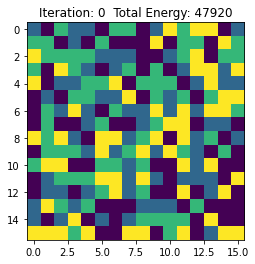


 Iteration # 1
Letter State 
 [['B' 'A' 'C' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'D' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

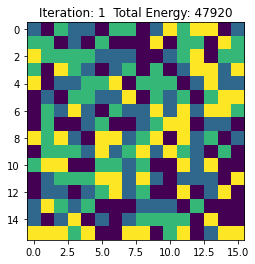


 Iteration # 2
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

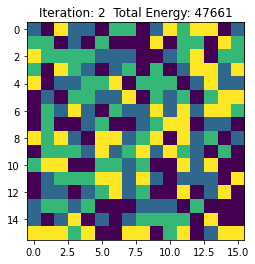


 Iteration # 3
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

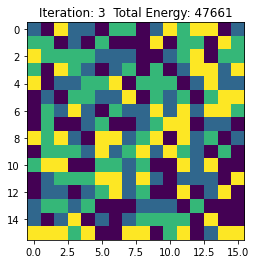


 Iteration # 4
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

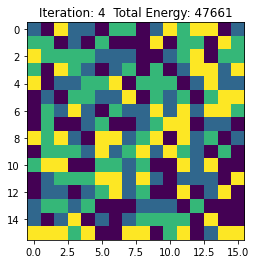


 Iteration # 5
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

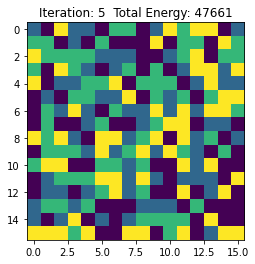


 Iteration # 6
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'B' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'A' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

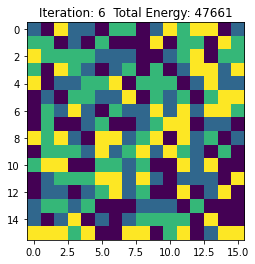


 Iteration # 7
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'B' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'A' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

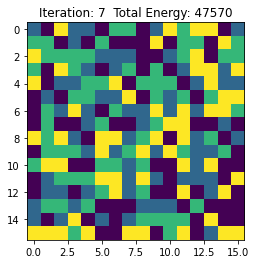


 Iteration # 8
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'B' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'A' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

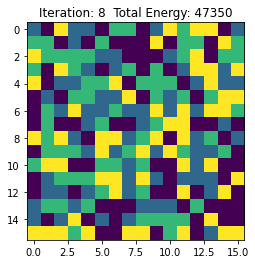


 Iteration # 9
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'C' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'A' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' '

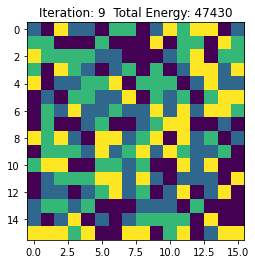


 Iteration # 10
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

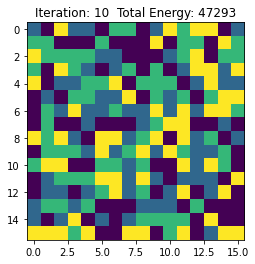


 Iteration # 11
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'D' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'C' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

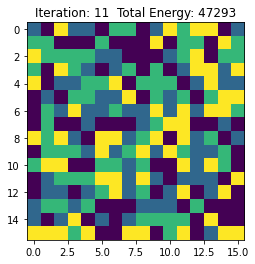


 Iteration # 12
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

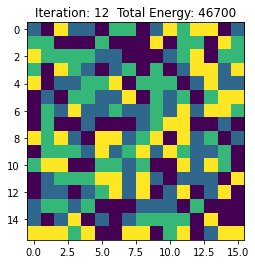


 Iteration # 13
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'B' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'C' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

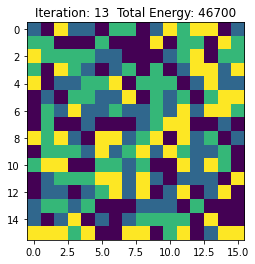


 Iteration # 14
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

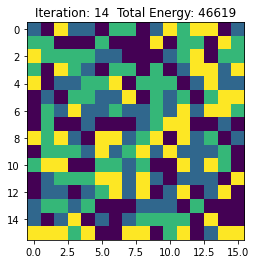


 Iteration # 15
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'A' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'B' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

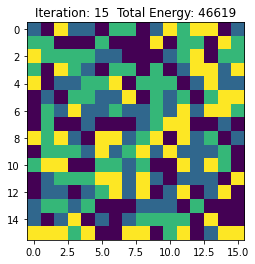


 Iteration # 16
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'C' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'B' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

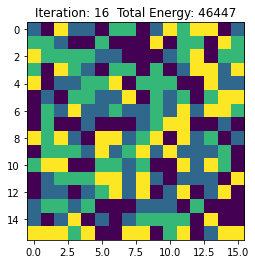


 Iteration # 17
Letter State 
 [['B' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'A' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

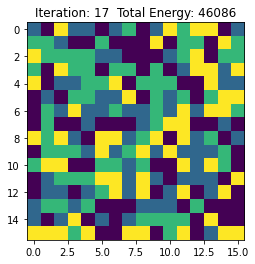


 Iteration # 18
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'B' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'A']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

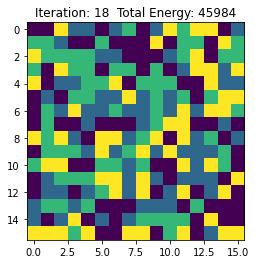


 Iteration # 19
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

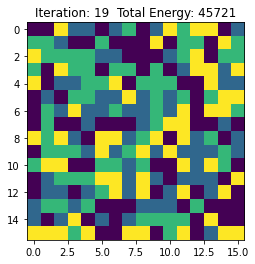


 Iteration # 20
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'A' 'B' 'A' 

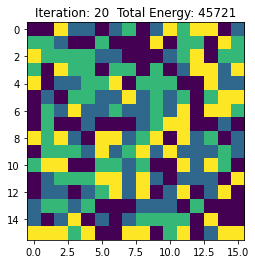


 Iteration # 21
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'D' 'B' 'A' 

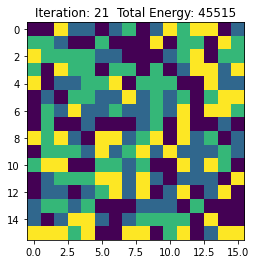


 Iteration # 22
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'D' 'B' 'A' 

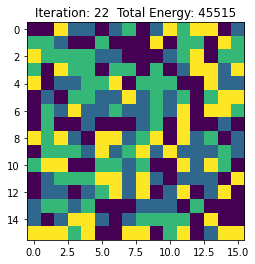


 Iteration # 23
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'C' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'D' 'B' 'A' 

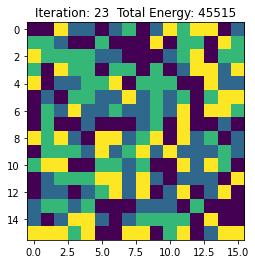


 Iteration # 24
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'D' 'B' 'A' 

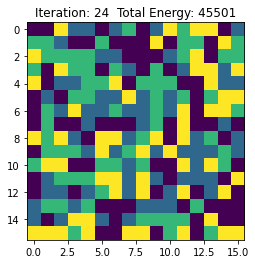


 Iteration # 25
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'D' 'B' 'A' 

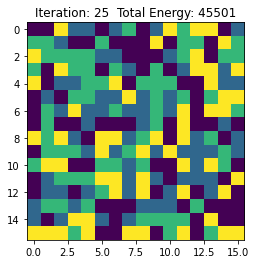


 Iteration # 26
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'A']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'B' 'D' 'D' 'B' 'A' 

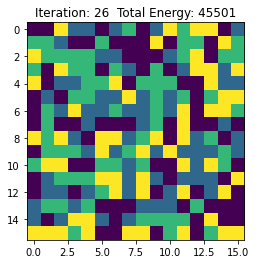


 Iteration # 27
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'B' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'C' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

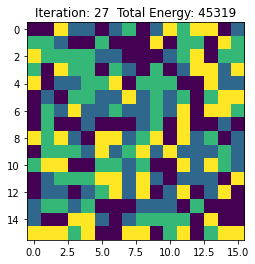


 Iteration # 28
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'A' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

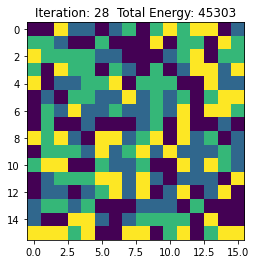


 Iteration # 29
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

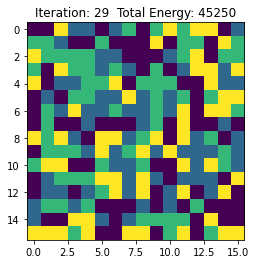


 Iteration # 30
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'D' 'D' 'C']
 ['A' 'C' 'A' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

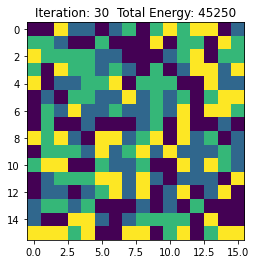


 Iteration # 31
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'C']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

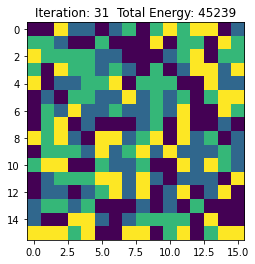


 Iteration # 32
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['C' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'C']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

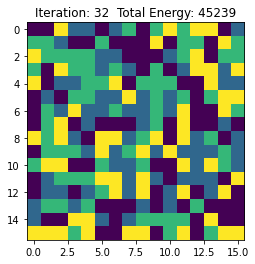


 Iteration # 33
Letter State 
 [['A' 'A' 'D' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'C']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'A' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

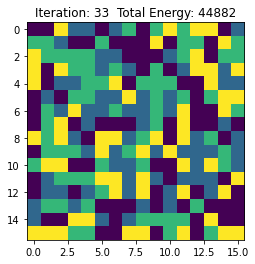


 Iteration # 34
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'C']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

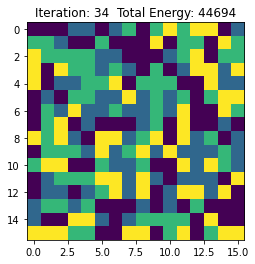


 Iteration # 35
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

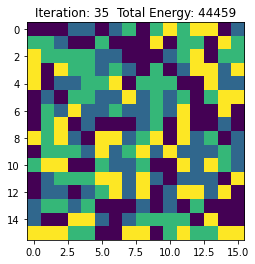


 Iteration # 36
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'A' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'D' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

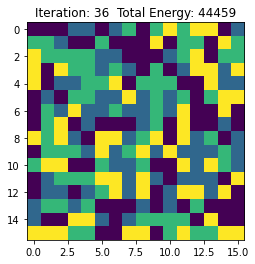


 Iteration # 37
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

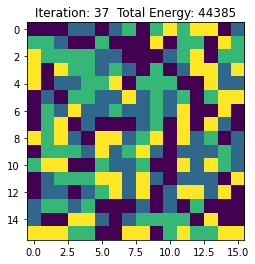


 Iteration # 38
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'C' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'A' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

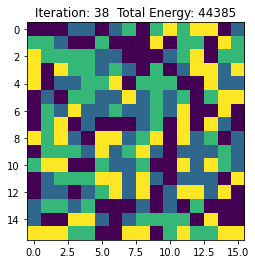


 Iteration # 39
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

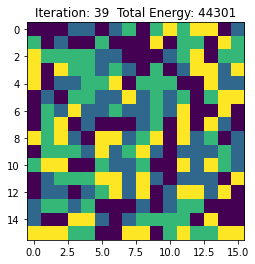


 Iteration # 40
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'B']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'C' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

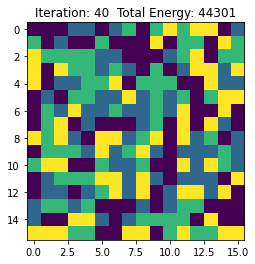


 Iteration # 41
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

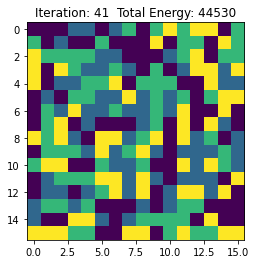


 Iteration # 42
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['A' 'C' 'C' 'C' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

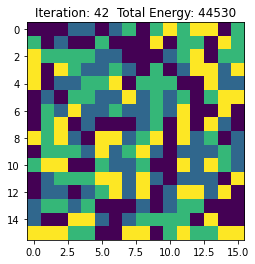


 Iteration # 43
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

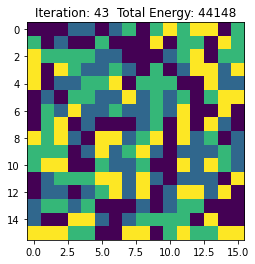


 Iteration # 44
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'B' 'B' 'B' 'A' 'D']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

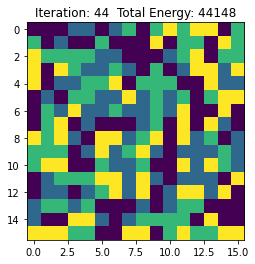


 Iteration # 45
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'D' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'A' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'B' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

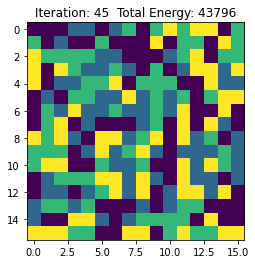


 Iteration # 46
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'D' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'B' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

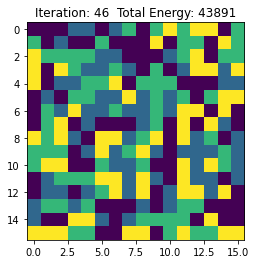


 Iteration # 47
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'A' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

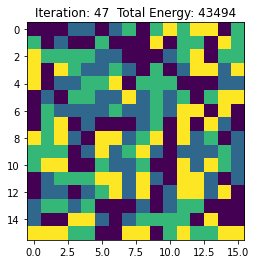


 Iteration # 48
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

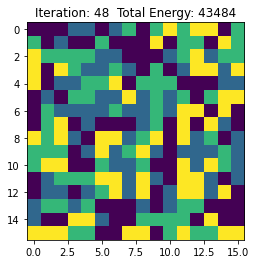


 Iteration # 49
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

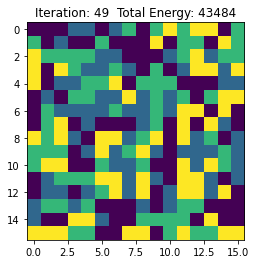


 Iteration # 50
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

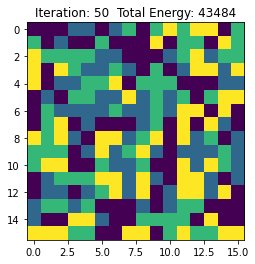


 Iteration # 51
Letter State 
 [['A' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'D']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

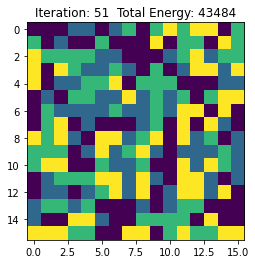


 Iteration # 52
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'C' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'B' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

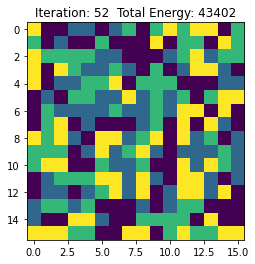


 Iteration # 53
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'A' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'D' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

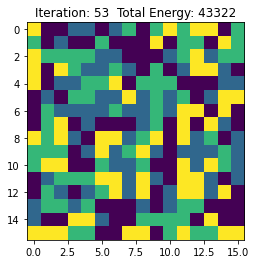


 Iteration # 54
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['A' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

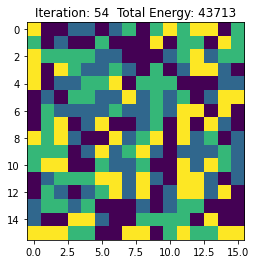


 Iteration # 55
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

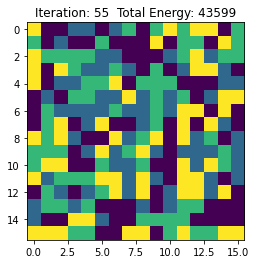


 Iteration # 56
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

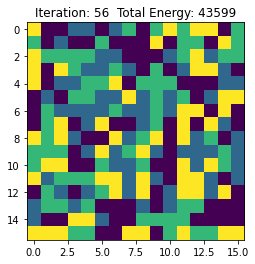


 Iteration # 57
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

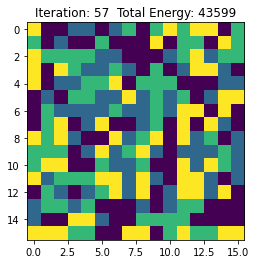


 Iteration # 58
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

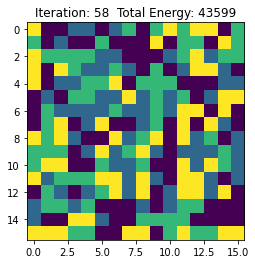


 Iteration # 59
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

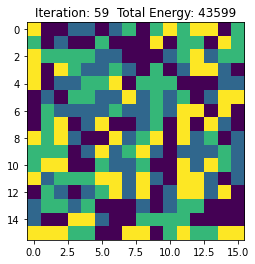


 Iteration # 60
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'D' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'B' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

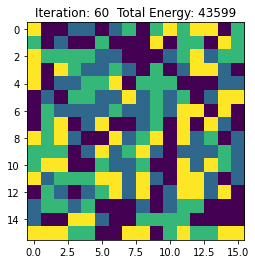


 Iteration # 61
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'C' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'D' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

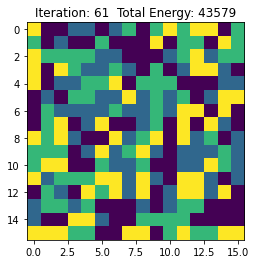


 Iteration # 62
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

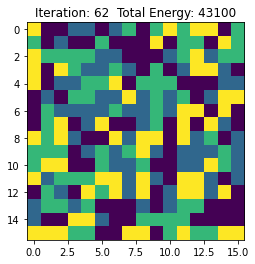


 Iteration # 63
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

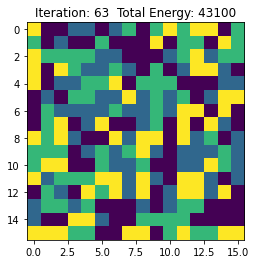


 Iteration # 64
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

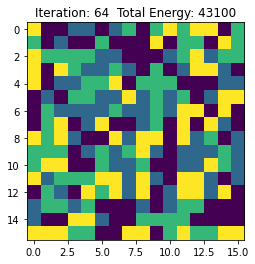


 Iteration # 65
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'C' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'D' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

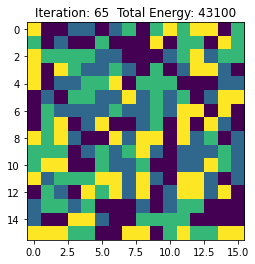


 Iteration # 66
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'B' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'A' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

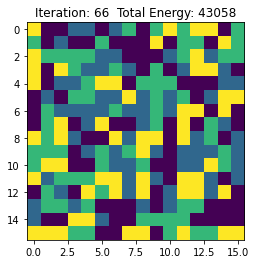


 Iteration # 67
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'C' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

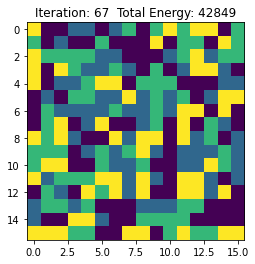


 Iteration # 68
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

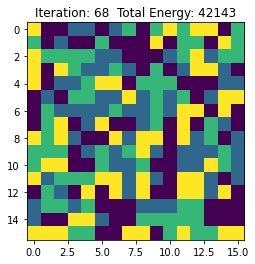


 Iteration # 69
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

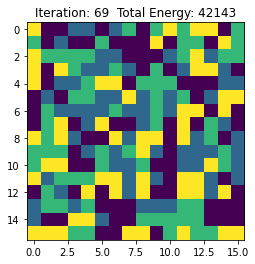


 Iteration # 70
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'C' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'A' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

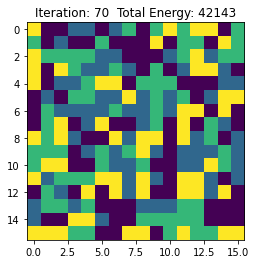


 Iteration # 71
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

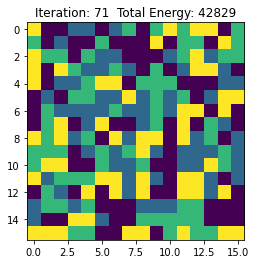


 Iteration # 72
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

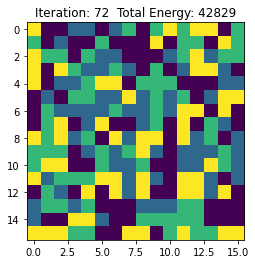


 Iteration # 73
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['C' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'D' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

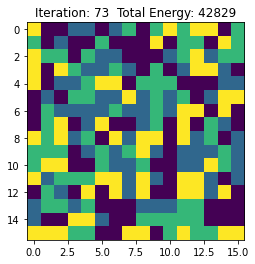


 Iteration # 74
Letter State 
 [['D' 'A' 'A' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'C' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'C' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

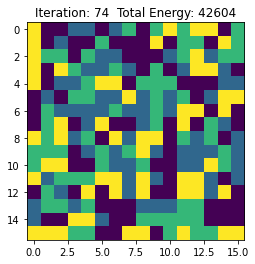


 Iteration # 75
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'C' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

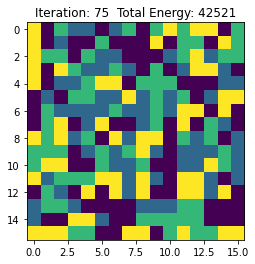


 Iteration # 76
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'C' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

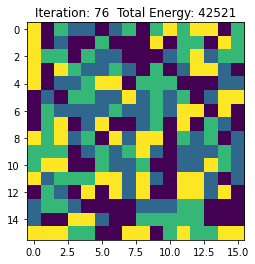


 Iteration # 77
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'C' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

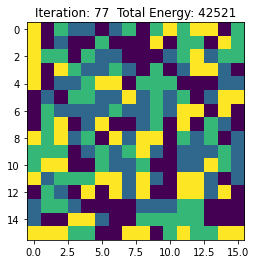


 Iteration # 78
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'C' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'B']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

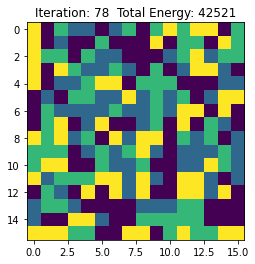


 Iteration # 79
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

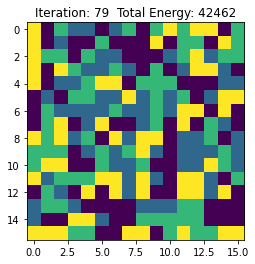


 Iteration # 80
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

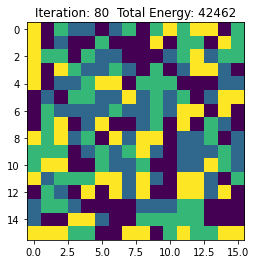


 Iteration # 81
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

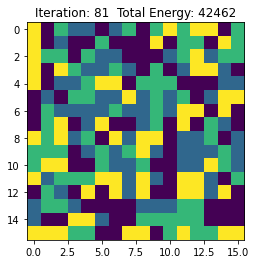


 Iteration # 82
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

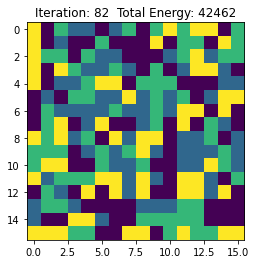


 Iteration # 83
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

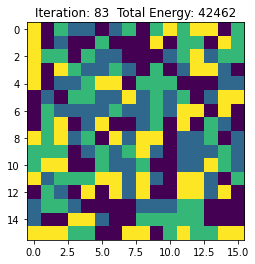


 Iteration # 84
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['D' 'C' 'D' 'B' 'C' 'A' 'D' 'B' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

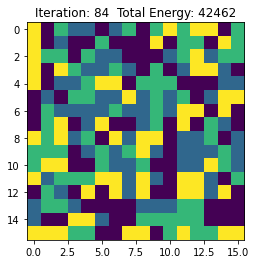


 Iteration # 85
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'A' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'C' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

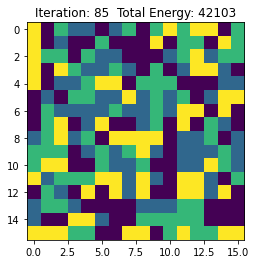


 Iteration # 86
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

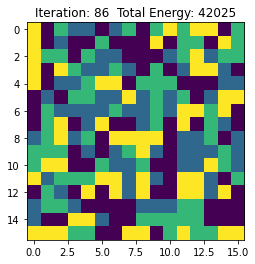


 Iteration # 87
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

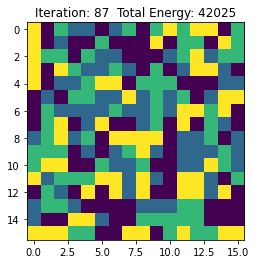


 Iteration # 88
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'D']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'C' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

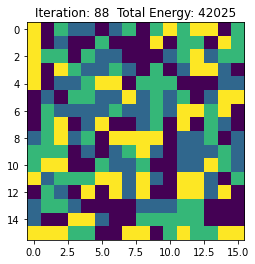


 Iteration # 89
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

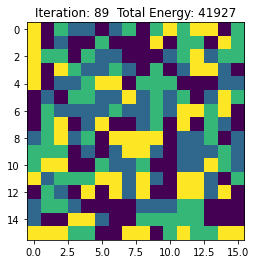


 Iteration # 90
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

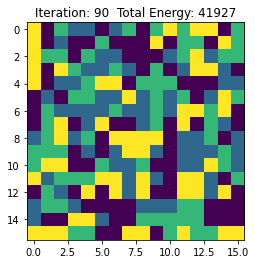


 Iteration # 91
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

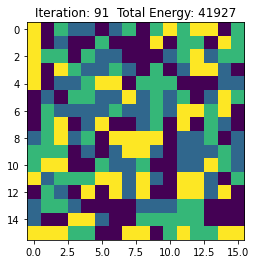


 Iteration # 92
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'C' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'A' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

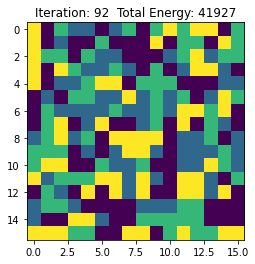


 Iteration # 93
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'A' 'A' 'D' 'A' 'C' 'C' 'A' 'D' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

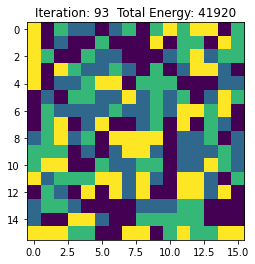


 Iteration # 94
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'D' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'A' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

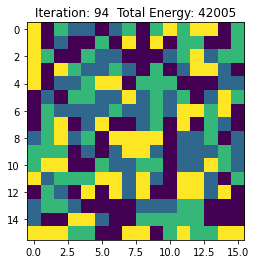


 Iteration # 95
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'A' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'B' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'D' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

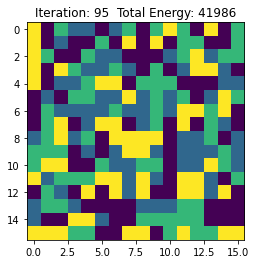


 Iteration # 96
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'A' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'D' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'D' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

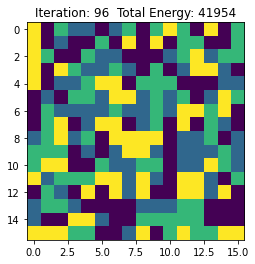


 Iteration # 97
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'A' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'D' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'D' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'D' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'B' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

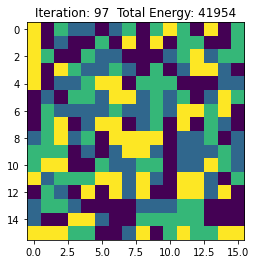


 Iteration # 98
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'A' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'B' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'D' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'D' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'D' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

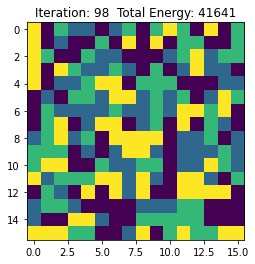


 Iteration # 99
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'A' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'B' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'D' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'D' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'D' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A' 

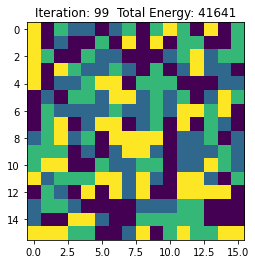


 Iteration # 100
Letter State 
 [['D' 'A' 'C' 'B' 'B' 'A' 'B' 'C' 'A' 'C' 'D' 'C' 'A' 'D' 'A' 'C']
 ['D' 'A' 'B' 'A' 'A' 'C' 'A' 'D' 'A' 'D' 'A' 'C' 'C' 'A' 'A' 'C']
 ['D' 'C' 'A' 'A' 'C' 'B' 'B' 'A' 'A' 'A' 'B' 'C' 'D' 'B' 'C' 'C']
 ['D' 'A' 'D' 'C' 'B' 'B' 'C' 'B' 'A' 'C' 'A' 'B' 'D' 'B' 'B' 'A']
 ['D' 'A' 'B' 'B' 'C' 'D' 'D' 'A' 'C' 'C' 'C' 'A' 'A' 'A' 'B' 'B']
 ['A' 'B' 'A' 'C' 'C' 'B' 'D' 'D' 'B' 'C' 'B' 'C' 'A' 'B' 'D' 'C']
 ['A' 'C' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'C' 'B' 'D' 'D' 'C' 'D' 'A']
 ['A' 'C' 'D' 'A' 'B' 'D' 'D' 'A' 'B' 'C' 'A' 'D' 'A' 'C' 'B' 'A']
 ['B' 'C' 'D' 'B' 'C' 'A' 'D' 'D' 'D' 'D' 'A' 'B' 'B' 'C' 'A' 'B']
 ['C' 'C' 'C' 'A' 'B' 'A' 'B' 'D' 'D' 'B' 'A' 'B' 'B' 'B' 'C' 'B']
 ['C' 'D' 'D' 'A' 'A' 'C' 'B' 'B' 'C' 'C' 'A' 'B' 'B' 'D' 'C' 'B']
 ['D' 'B' 'C' 'C' 'C' 'D' 'D' 'B' 'D' 'B' 'A' 'D' 'D' 'B' 'A' 'C']
 ['A' 'C' 'B' 'A' 'D' 'A' 'D' 'B' 'D' 'A' 'A' 'D' 'D' 'D' 'D' 'A']
 ['B' 'C' 'C' 'B' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'C' 'C' 'A' 'A' 'A']
 ['B' 'A' 'A' 'D' 'D' 'B' 'A'

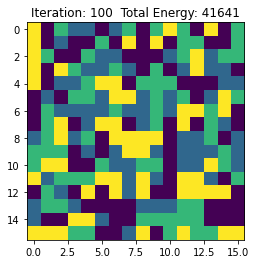

[[  0.          64.40492205 159.86728449 103.01152197]
 [ 64.40492205   0.         133.16440669 156.57179015]
 [159.86728449 133.16440669   0.         178.54659754]
 [103.01152197 156.57179015 178.54659754   0.        ]]


In [101]:
m = main_program(iterations = 100, ori_types = 4, rows = 16, columns = 16,
                 random_energy_matrix_flag = True)

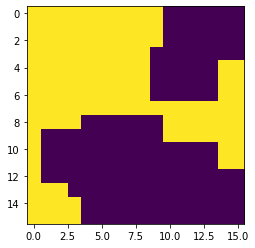

In [17]:
plt.imshow(m[500])

In [133]:
len(np.unique(m[1]))

2

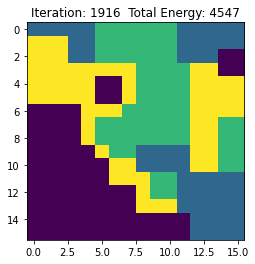

KeyboardInterrupt: 

In [267]:
model1 = main_program(iterations =1000, ori_types = 4, rows = 16, columns = 16, model = m)

In [210]:
len(model1)

21

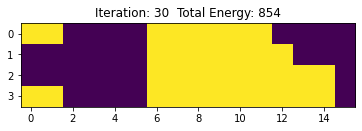

[[ 0.         50.27555404]
 [50.27555404  0.        ]]


In [211]:
model2 = main_program(iterations =10, ori_types = 2, rows = 4, columns = 16,
                 random_energy_matrix_flag = True, model = model1)

In [168]:
len(model2)

29

In [58]:
len(m[-1][0])

16

In [62]:
len(np.unique(m[-1]))

2

In [ ]:
np.shape(model1)
len(model1)

In [ ]:
#######
# Manual n_state, energy_matrix calc

In [70]:
n_stateZ = [
    [1,1,1],
    [1,1,0],
    [0,0,0]
]
ori_types = 2
rows = 3
columns = 3
                 
energy_matrixZ = [
    [0, 5], 
    [5, 0] 
]

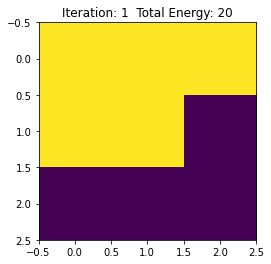

Letter State 
 [['B' 'B' 'B']
 ['B' 'B' 'A']
 ['A' 'A' 'A']]
Number of  A - A orientations is  3
Number of  A - B orientations is  4
Number of  B - B orientations is  5
Total Energy of State is  20.0


In [71]:
mis_ori_matrixZ = mis_ori_calculator(n_stateZ, rows, columns, ori_types)    
total_energyZ = state_energy(mis_ori_matrixZ, energy_matrixZ)
disp_im(n_stateZ, total_energyZ)
disp_letter_matrix(n_stateZ, rows, columns)
disp_mis_ori_calculations(mis_ori_matrixZ, energy_matrixZ, total_energyZ)

In [262]:
mis_ori_matrixZ

array([[ 6,  4],
       [ 4, 10]])

In [239]:
mq[1][1]

21261.770406107993

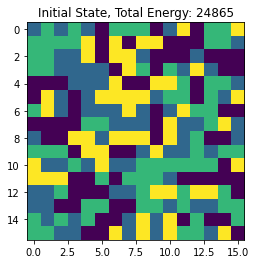

In [290]:
#print("\n")
plt.title("Initial State, Total Energy: %d" %(m[1][1]))
plt.imshow(m[1][0])
plt.show()

In [ ]:
next_state_swap(n_stateZ, ori_typesZ, mis_ori_matrixZ, energy_matrixZ, total_energyZ)

In [ ]:
def disp_im(n_state, total_energy, i = 1):

    #print(n_state)
    #plt.title("Iteration: %d  Total Energy: %d" %(i, total_energy))
    plt.pause(2)
    if is_ipython: 
        display.clear_output(wait=True)   # Make it false for quick execution

    plt.imshow(n_state)
    plt.show()

In [ ]:
a,s = 0,0
a = 2
s         # 0

In [ ]:
a,b,c,d = np.random.randint(0,2,4)

In [ ]:
a,b,c,d

In [ ]:
Q = [[1,2,3], [4,5,6]]
len(Q[0])

In [ ]:
a= [[1,2,3], [4,5,6]]
b = [[7,8,9], [11,12,13]]
(np.multiply(np.array(a), np.array(b)))
np.shape(a)[0]

In [ ]:
# randomly gives new ori to a randomly chosen lattice pt (i,j)
def next_state_random_ori_chosen(n_state, mis_ori_matrix, ori_types):
    next_state = n_state
    i = np.random.randint(0, len(next_state))     # A random row is chosen
    j = np.random.randint(0, len(next_state[0]))
    
    new_ori = np.random.randint(0, ori_types)
    
    while(next_state[i][j] == new_ori):                 # Making sure that i,j gets a new ori
        new_ori = np.random.randint(0, ori_types)
        
    next_state[i][j] = new_ori

    old_pt_mis_ori_matrix = np.zeros(shape = (ori_types, ori_types), dtype = int)
    new_pt_mis_ori_matrix = np.zeros(shape = (ori_types, ori_types), dtype = int)
    ori_array = list(range(0, ori_types))         
    
    old_pt_mis_ori_matrix = mis_ori_calculator(n_state, ori_array, old_pt_mis_ori_matrix, i, j) 
    new_pt_mis_ori_matrix = mis_ori_calculator(next_state, ori_array, new_pt_mis_ori_matrix, i, j) 
    
    next_state_mis_ori_matrix = mis_ori_matrix - old_pt_mis_ori_matrix + new_pt_mis_ori_matrix
    
    return next_state, next_state_mis_ori_matrix

In [ ]:
material_state(ori_types = 4, rows = 2, columns = 3) # Old

In [ ]:
mis_ori_matrix = np.zeros(shape = (ori_types, ori_types), dtype = int)
print(mis_ori_matrix )

In [ ]:
n_state, len(n_state), len(n_state[0]), len(n_state[1])

In [ ]:
for i in range(len(n_state)):
    print(i)

In [ ]:
chr(65)

In [ ]:
for i in range(len(n_state)):
    for j in range(len(n_state[0])):
        l_state[i][j] = chr(n_state[i][j]+65)

print(n_state)
print(l_state) 
print(mis_ori_matrix)

In [ ]:
for i in range(len(mis_ori_matrix)):
    for j in range(i, len(mis_ori_matrix[0])):
        if i == j:
            print("Number of ",chr(65+i),"-",chr(65+j),"mis_oris is ", str( int((mis_ori_matrix[i][j]+mis_ori_matrix[j][i])/4)) )
        else:
            print("Number of ",chr(65+i),"-",chr(65+j),"mis_oris is ", str( int((mis_ori_matrix[i][j]+mis_ori_matrix[j][i])/2)) )

In [ ]:
for i in range(len(mis_ori_matrix)):
    for j in range(i, len(mis_ori_matrix[0])):
        print("Number of ",chr(65+i),"-",chr(65+j),"mis_oris is ", str( int((mis_ori_matrix[i][j]+mis_ori_matrix[j][i])/2)) )

In [ ]:
len(mis_ori_matrix), len(mis_ori_matrix[0])

In [ ]:
for i in range(len(n_state)):
    for j in range(len(n_state[0])):
        if (i+j) % 2 == 0:
            neighbour_mis_ori(i, j, n_state, mis_ori_matrix)
        

In [ ]:
def neighbour_mis_ori(i, j, n_state, mis_ori_matrix):
    m = len(n_state)
    n = len(n_state[0])
    
    ori_array = list(range(0, ori_types))                                    # 0 (A), 1(B), 2(C), ....
    for k in range(len(ori_array)):
        if n_state[i][j] == ori_array[k]:
            
            if i-1 >= 0:                                                     # Up-ori
                for l in range(len(ori_array)):
                    if n_state[i-1][j] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1
                        
            if j-1 >= 0:                                                    # Left-ori
                for l in range(len(ori_array)):
                    if n_state[i][j-1] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1
                        
            if i+1 <= m-1:                                                   # Bottom-ori
                for l in range(len(ori_array)):
                    if n_state[i+1][j] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1
                        
            if j+1 <= n-1:                                                   # Right-ori
                for l in range(len(ori_array)):
                    if n_state[i][j+1] == ori_array[l]:
                        mis_ori_matrix[ori_array[k]][ori_array[l]] +=1
                        mis_ori_matrix[ori_array[l]][ori_array[k]] +=1
                
                
    

In [ ]:
mis_ori_matrix

In [ ]:
len(n_state), len(n_state[0])

In [ ]:
a= 9
def q(a):
    a = copy.deepcopy(a)
    a = 4
    print(a)
q(a)
a

In [ ]:
q = [[[1,2,3],
     [4,5,6],
     [7,8,9]],
     
     [[10,11,12],
      [13,14,15],
      [16,17,18]],
     
     [[19,20,21],
     [22,23,24],
     [25,26,27]]]

In [ ]:
q = np.array([1,8,8,2])
print(set(q), ori_array)
for i in range(len(set(q))):
    print("i", i)
    if ori_array[i] == np.any(q):
        continue
    else:
        
        z = list(np.where(q == np.max(q)) [0])
        print(i, z)
        q[z] = ori_array[i]
      
q = np.array(q)
w = np.array([q])
e = np.reshape(w, (2,2))
print(q,w)
#q.reshape(np.array((2,2)))
print(q.size, type(w), e)
w((2,2))

In [ ]:
z = np.where(q == np.max(q)) [0]
z
print(q)
q[z] = 23
q

In [ ]:
ori_array = list(range(0, ori_types))
#while (len(set(q)) != np.max(q) + 1):
uni = list(set(q))
print(uni)
print(ori_array)
qs = sorted(q)
print(qs)
for i in range(len(q)):
    pass

In [ ]:
W = np.array([[1,2],[3,4]])
print(W)
print(np.transpose(W))

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from IPython import display

n = 10
plt.figure()
a = np.zeros((n, n))
for i in range(n):
    
    a[i, i] = 1
    plt.pause(0.1)
    display.clear_output(wait=True)
    plt.imshow(a)
    plt.show()

In [51]:
def func(A):
    A[0][0] += 10
    return A
      
qw = np.array([[1,2], [3,4]])
print(qw)
qw = func(qw) * -1
print(qw)
      

[[1 2]
 [3 4]]
[[-11  -2]
 [ -3  -4]]


In [53]:
qw = np.array([1,2])
qa = np.array([3,4])
print(qw-qa)

[-2 -2]


In [43]:
lst = [1,1,7,7,7,1,2]
most_freq = max(lst,key=lst.count)
freq = lst.count(most_freq)
print(most_freq,"occurs", freq, "times")

1 occurs 3 times


In [40]:
from collections import Counter
Counter(lst)

Counter({1: 3, 7: 3, 2: 1})

In [1]:
def f(A,B):     # everything is call by reference
    A[0][0] +=1
    B +=1
    return A,B
    

In [2]:
a = [[1,2],[3,4]]
b = 9
for i in range(5):
    a,b = f(a,b)

print(a,b)

[[6, 2], [3, 4]] 14
